# Laboratory Session 3

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules

In [2]:
st=pd.read_csv('store.csv', sep=',', header=None)
print(st.head(10))

                  0             1           2                 3   \
0             shrimp       almonds     avocado    vegetables mix   
1            burgers     meatballs        eggs               NaN   
2            chutney           NaN         NaN               NaN   
3             turkey       avocado         NaN               NaN   
4      mineral water          milk  energy bar  whole wheat rice   
5     low fat yogurt           NaN         NaN               NaN   
6  whole wheat pasta  french fries         NaN               NaN   
7               soup   light cream     shallot               NaN   
8  frozen vegetables     spaghetti   green tea               NaN   
9       french fries           NaN         NaN               NaN   

             4                 5     6               7             8   \
0  green grapes  whole weat flour  yams  cottage cheese  energy drink   
1           NaN               NaN   NaN             NaN           NaN   
2           NaN               Na

In [3]:
uitems=st[0].unique()
print(uitems)

['shrimp' 'burgers' 'chutney' 'turkey' 'mineral water' 'low fat yogurt'
 'whole wheat pasta' 'soup' 'frozen vegetables' 'french fries' 'eggs'
 'cookies' 'spaghetti' 'meatballs' 'red wine' 'rice' 'parmesan cheese'
 'ground beef' 'sparkling water' 'herb & pepper' 'pickles' 'energy bar'
 'fresh tuna' 'escalope' 'avocado' 'tomato sauce' 'clothes accessories'
 'energy drink' 'chocolate' 'grated cheese' 'yogurt cake' 'mint'
 'asparagus' 'champagne' 'ham' 'muffins' 'french wine' 'chicken' 'pasta'
 'tomatoes' 'pancakes' 'frozen smoothie' 'carrots' 'yams' 'shallot'
 'butter' 'light mayo' 'pepper' 'candy bars' 'cooking oil' 'milk'
 'green tea' 'bug spray' 'oil' 'olive oil' 'salmon' 'cake' 'almonds'
 'salt' 'strong cheese' 'hot dogs' 'pet food' 'whole wheat rice'
 'antioxydant juice' 'honey' 'sandwich' 'salad' 'magazines' 'protein bar'
 'mayonnaise' 'cider' 'burger sauce' 'green grapes' 'vegetables mix'
 'bramble' 'nonfat milk' 'tomato juice' 'green beans' 'strawberries'
 'eggplant' 'mushroom cre

In [4]:
itemset=set(uitems)
envals=[]
for idx, row in st.iterrows():
    rowset=set(row)
    labels={}
    uncomms=list(itemset-rowset)
    commons=list(itemset.intersection(rowset))
    for uc in uncomms:
        labels[uc]=0
    for cm in commons:
        labels[cm]=1
    envals.append(labels)

In [5]:
stdt=pd.DataFrame(envals)
fitems=apriori(stdt, min_support=0.05, use_colnames=True, verbose=1)
print(fitems.head(10))

Processing 600 combinations | Sampling itemset size 2
    support             itemsets
0  0.051060        (cooking oil)
1  0.179709               (eggs)
2  0.052393      (grated cheese)
3  0.095321  (frozen vegetables)
4  0.129583               (milk)
5  0.081056               (cake)
6  0.174110          (spaghetti)
7  0.087188            (burgers)
8  0.080389            (cookies)
9  0.079323           (escalope)


In [6]:
arl=association_rules(fitems, metric='confidence', min_threshold=0.15)
print(arl.head())

       antecedents      consequents  antecedent support  consequent support  \
0           (eggs)  (mineral water)            0.179709            0.238368   
1  (mineral water)           (eggs)            0.238368            0.179709   
2      (spaghetti)  (mineral water)            0.174110            0.238368   
3  (mineral water)      (spaghetti)            0.238368            0.174110   
4      (chocolate)  (mineral water)            0.163845            0.238368   

    support  confidence      lift  leverage  conviction  
0  0.050927    0.283383  1.188845  0.008090    1.062815  
1  0.050927    0.213647  1.188845  0.008090    1.043158  
2  0.059725    0.343032  1.439085  0.018223    1.159314  
3  0.059725    0.250559  1.439085  0.018223    1.102008  
4  0.052660    0.321400  1.348332  0.013604    1.122357  


<function matplotlib.pyplot.show(close=None, block=None)>

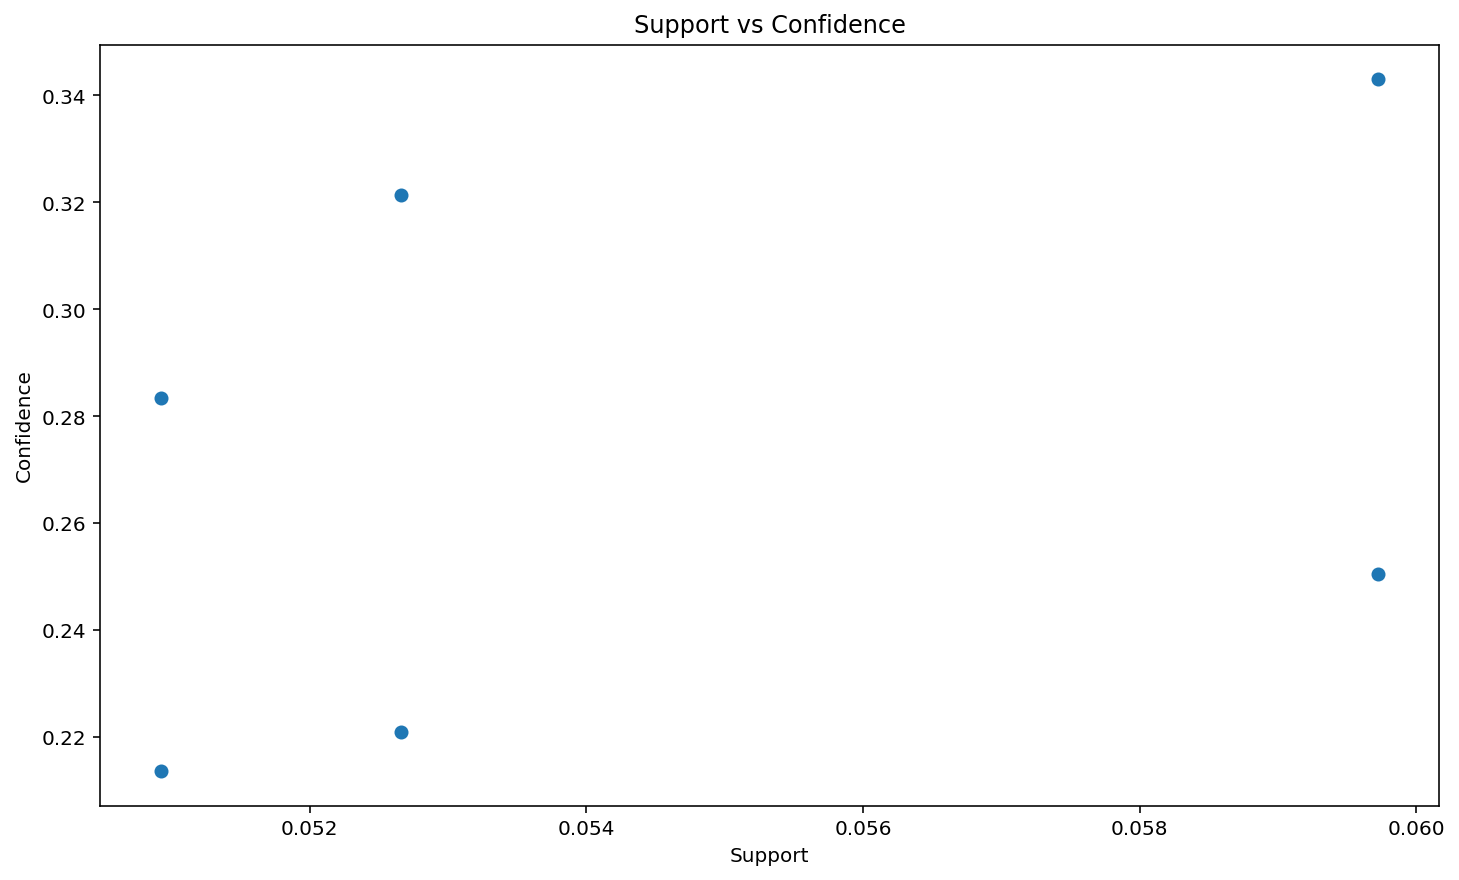

In [7]:
plt.scatter(arl['support'], arl['confidence'], alpha=1)
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Support vs Confidence')
plt.show